In [1]:
!pwd

/truejit/evaluation/network-latency-impact


In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import bokeh.palettes

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
})

In [3]:
# visualise the latency and compilation for every latency:
# **compilation**
# delays:			0		1		2		10
# remote jit 		9057	9057	9080	9098
# truejit			1840	1789	1802	1408
# 
# **latency**
# delays:			0		1		2		10
# remote jit 		9616	10454	11418	18284
# truejit			1891	1931	2036	2210

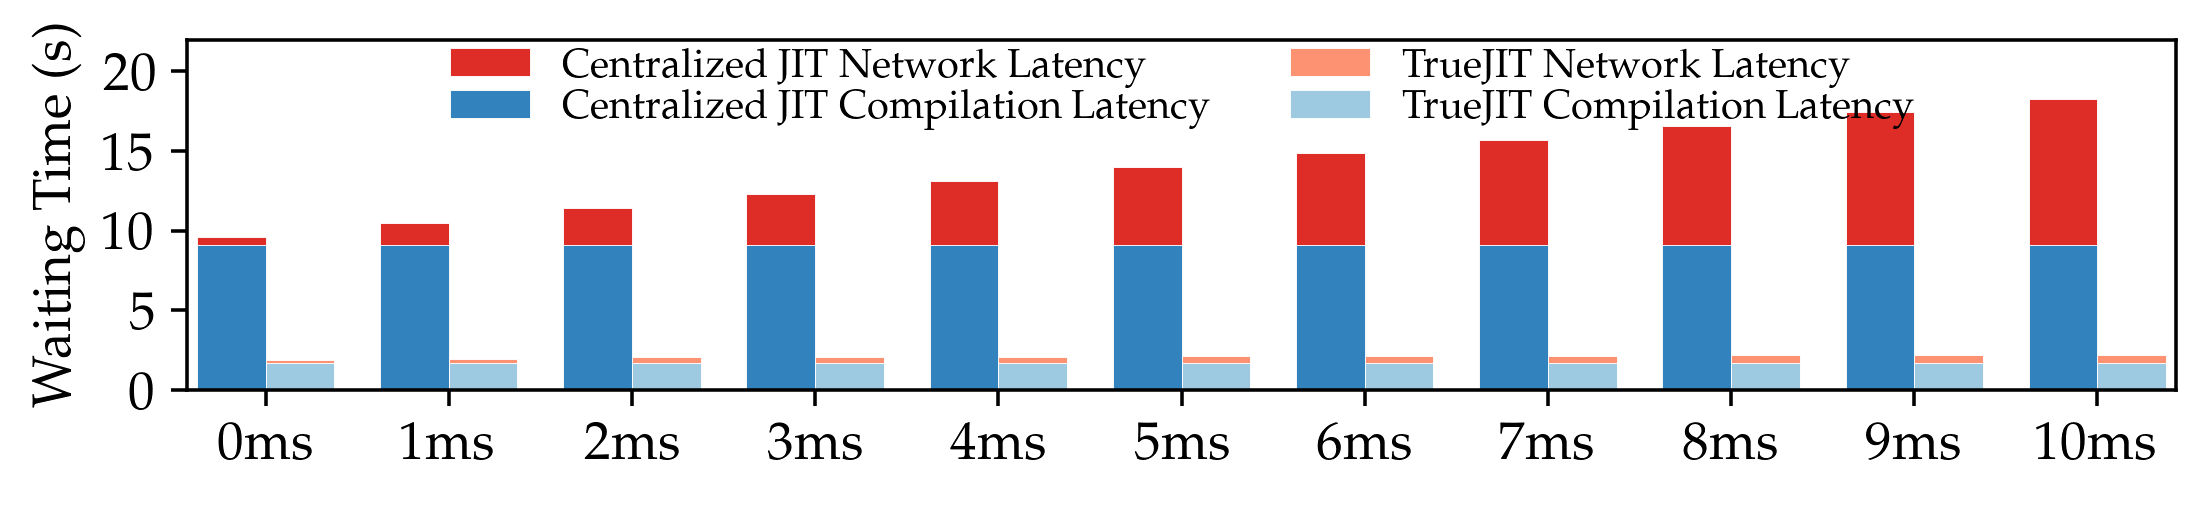

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import bokeh

reds = bokeh.palettes.Reds[3]
blues = bokeh.palettes.Blues[3]

# figure
width = 7
height = 1.7
fig, ax = plt.subplots(figsize=(width, height), dpi=320)

# bar width
bar_width = 0.75

# data
network_latencies = [0, 1, 2, 10]
centralized_jit_compilation_times = [9057, 9057, 9080, 9098]
truejit_compilation_times = [1840, 1789, 1802, 1408]
centralized_jit_total_time = [9616, 10454, 11418, 18284]
truejit_total_time = [1891, 1931, 2036, 2210]

# interpolation for latency
num_items = network_latencies[-1] - network_latencies[0] + 1
interpolation_range = np.linspace(network_latencies[0], network_latencies[-1], num=num_items, endpoint=True)
centralized_jit_compilation_times = [sum(centralized_jit_compilation_times) / len(
    centralized_jit_compilation_times)] * num_items
truejit_compilation_times = [sum(truejit_compilation_times) / len(truejit_compilation_times)] * num_items
centralized_jit_total_time = np.interp(interpolation_range, network_latencies, centralized_jit_total_time)
truejit_total_time = np.interp(interpolation_range, network_latencies, truejit_total_time)
network_latencies = interpolation_range
# print(f'network_latencies: {network_latencies}')

# for opt, network_latency in enumerate(network_latencies):
# centralized_jit_total
edgecolor = 'white'
linewidth = 0.2
width = bar_width / 2
centralized_x = network_latencies - (bar_width / 4)
ax.bar(centralized_x, centralized_jit_total_time, width=width, edgecolor=edgecolor, linewidth=linewidth, color=reds[0],
       label='Centralized JIT Network Latency')
ax.bar(centralized_x, centralized_jit_compilation_times, width=width, edgecolor=edgecolor, linewidth=linewidth,
       color=blues[0],
       label='Centralized JIT Compilation Latency')
truejit_x = network_latencies + (bar_width / 4)
ax.bar(truejit_x, truejit_total_time, color=reds[1],
       label='TrueJIT Network Latency',
       width=width, edgecolor=edgecolor, linewidth=linewidth)
# truejit_compilation
ax.bar(truejit_x, truejit_compilation_times, color=blues[1],
       label='TrueJIT Compilation Latency',
       width=width, edgecolor=edgecolor, linewidth=linewidth)

# xticks
ax.set_xticks(network_latencies, [f'{int(x)}ms' for x in network_latencies], fontsize=12)
ax.set_ylabel('Waiting Time (s)', fontsize=12)

# y-axis 
# to seconds
xs = range(0, 20000 + 1, 5000)
ax.set_yticks(xs, [f'{x // 1000}' for x in xs], fontsize=12)

# y limit
ax.set_ylim(0, 22000)

# margin
ax.margins(0.005)

ax.legend(loc='upper center',
          ncol=2,
          frameon=False,
          bbox_to_anchor=(0.5, 1.08),
          fontsize=9,
          # row spacing
          labelspacing=0.05,
          title_fontsize='small')

# layout 
plt.tight_layout()

# to pdf
plt.savefig('out/network_latency_impact_on_waiting_time.pdf', bbox_inches='tight', pad_inches=0.05, dpi=320,
            format='pdf')

plt.show()